# Paid-Conversion Model: Ranking Users for Premium Upsell

The last roadmap item: rank not-yet-paying users by their probability of starting a paid plan within 30 days, so a premium-upsell campaign concentrates outreach where it pays. This is a **ranking problem under class imbalance** — every choice below (metrics, models, evaluation) follows from that framing, not from accuracy.

The protocol is frozen in `src/conversion_modeling.py` + `sql/build_conversion_table.sql` the way `src/churn_modeling.py` froze notebook 05's, and its headline baseline metrics are persisted in the module docstring so any future conversion notebook can gate against them the way notebook 07 gated against 05.

**Dependencies:** `sql/build_conversion_table.sql`; the shared evaluation harness in `src/model_evaluation.py` (paired bootstrap, calibration, lift table — reused, not reimplemented); the notebook-07 tuned GBM configuration imported from `src/churn_modeling.py`.

## 1. Label and Population Audit

Before modeling: what does "conversion" even mean in this data? Three candidate numbers exist, and only one of them defines a trainable problem.

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve

from src.config import RANDOM_SEED
from src.churn_modeling import TUNED_GBM_PARAMS, build_preprocessor
from src.conversion_modeling import load_conversion_split
from src.data_loader import connect, load_table
from src.model_evaluation import (
    calibration_table,
    evaluate_models,
    lift_table,
    paired_bootstrap_auc_delta,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

LR_COLOR, GBM_COLOR, NEUTRAL_COLOR = "#1f77b4", "#ff7f0e", "#7f7f7f"

# --- Audit: the snapshot framing is degenerate ---
snapshot = load_table("feature_table")
snapshot_free = snapshot[snapshot["subscription_type"].isin(["free", "trial"])]
print("Candidate 1 — 'free/trial at the snapshot, converted in-window':")
print(f"  {len(snapshot_free):,} users, "
      f"{int(snapshot_free['paid_conversion_30d'].sum())} positives "
      f"({snapshot_free['paid_conversion_30d'].mean():.2%}) — untrainable: "
      "in-window converters are already premium at the snapshot")
print("Candidate 2 — the README's 17.4% baseline:")
print(f"  share of ALL {len(snapshot):,} users with a paid start inside the "
      f"observation window = {snapshot['paid_conversion_30d'].mean():.1%} — "
      "a population-wide window rate, not a forward probability")

conn, sql, run_script = connect()
run_script((REPO_ROOT / "sql" / "build_conversion_table.sql").read_text())
conversion = sql("SELECT * FROM conversion_table")
print("Candidate 3 — the landmark design (this notebook):")
print(f"  {len(conversion):,} never-paid users at 2026-03-02, "
      f"{int(conversion['paid_conversion_next_30d'].sum()):,} convert in the "
      f"next 30 days ({conversion['paid_conversion_next_30d'].mean():.1%})")

Candidate 1 — 'free/trial at the snapshot, converted in-window':
  31,255 users, 30 positives (0.10%) — untrainable: in-window converters are already premium at the snapshot
Candidate 2 — the README's 17.4% baseline:
  share of ALL 50,000 users with a paid start inside the observation window = 17.4% — a population-wide window rate, not a forward probability


Loaded tables: users, listening_events, subscription_events, ad_events, feature_table


Candidate 3 — the landmark design (this notebook):
  37,311 never-paid users at 2026-03-02, 7,875 convert in the next 30 days (21.1%)


The landmark design shifts the clock back one month: population = users with **no paid start before 2026-03-02**, label = paid start in the following 30 days, features = behavior strictly before the landmark. Same business question — "which not-yet-paying users are about to convert?" — but with 7,875 positives instead of 30, and leakage impossible by construction (the audit above is why the protocol module exists: this is the kind of decision that must be frozen, not re-derived per notebook).

**Do notebook 03/04's correlational conversion drivers survive in this cohort?**

In [2]:
by_channel = (conversion.groupby("acquisition_channel")["paid_conversion_next_30d"]
              .agg(users="size", conversion_rate="mean")
              .sort_values("conversion_rate", ascending=False))
engaged = (conversion["playlist_adds_w"] + conversion["liked_songs_w"]) > 0
by_engagement = (conversion.groupby(engaged.rename("playlist_or_like_w"))
                 ["paid_conversion_next_30d"].agg(users="size", conversion_rate="mean"))
print("Forward 30-day conversion by acquisition channel:")
print(by_channel.round(3).to_string())
print("\nBy content engagement in the feature window:")
print(by_engagement.round(3).to_string())

Forward 30-day conversion by acquisition channel:
                     users  conversion_rate
acquisition_channel                        
referral              4494            0.299
influencer            3015            0.230
student_partner       2957            0.222
app_store             9404            0.213
email_campaign        1496            0.213
organic_search        8883            0.208
paid_social           7062            0.143

By content engagement in the feature window:
                    users  conversion_rate
playlist_or_like_w                        
False               24100            0.163
True                13211            0.299


Both survive: **referral converts at 29.9% vs paid social's 14.3%** (notebook 04 ranked exactly these channels top and bottom), and **content engagement nearly doubles conversion** (29.9% vs 16.3%), echoing notebook 03's playlist finding. The correlational story and the predictive cohort agree.

## 2. Protocol

| Element | Choice |
|---|---|
| Population | 37,311 users never paid as of the 2026-03-02 landmark |
| Label | `paid_conversion_next_30d` — paid start in [2026-03-02, 2026-04-01); base rate **21.1%** |
| Features | 19 numeric + 5 categorical, all aggregated from events **before** the landmark; payment/plan/revenue columns are banned by `assert_leakage_safe` because they encode the label or post-landmark state |
| Split | Stratified 80/20, project seed, frozen in `load_conversion_split()` |
| Preprocessing | The house transformer (scaled numerics + one-hot categoricals), reused from `src/churn_modeling.py` |
| Class imbalance | **No reweighting.** Weighting reshapes 0.5-threshold metrics but leaves the ranking essentially unchanged — and it wrecks the calibrated probabilities that campaign budgeting needs. A ranking problem is handled in the metric, not the loss. |
| Headline metric | **PR-AUC.** At a 21% base rate, ROC-AUC is inflated by the easy negatives (a model can look great while its top-of-list precision decays); PR-AUC scores exactly the region a campaign uses — precision among the users you would actually contact. ROC-AUC is reported for comparability. |

## 3. Models

Logistic regression baseline plus the notebook-07 tuned HistGB configuration, imported rather than re-tuned: notebook 07 established that GBMs tie logistic regression on churn in this data, and the cheap test of whether that transfers to conversion is to reuse the tuned config as-is.

In [3]:
split = load_conversion_split()
print(f"Train: {split.X_train.shape}, test: {split.X_test.shape}, "
      f"test base rate: {split.y_test.mean():.3f}")

log_model = Pipeline([
    ("preprocess", build_preprocessor(split.numeric_features, split.categorical_features)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
gbm_model = Pipeline([
    ("preprocess", build_preprocessor(split.numeric_features, split.categorical_features,
                                      dense=True)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED,
                                             **TUNED_GBM_PARAMS)),
])
log_model.fit(split.X_train, split.y_train)
gbm_model.fit(split.X_train, split.y_train)
models = {"logistic_regression": log_model, "hist_gradient_boosting": gbm_model}

metrics_table = evaluate_models(models, split.X_test, split.y_test)
metrics_table.round(4)

Loaded tables: users, listening_events, subscription_events, ad_events, feature_table


Train: (29848, 24), test: (7463, 24), test base rate: 0.211


,model,roc_auc,pr_auc,brier,precision_at_threshold,recall_at_threshold,f1_at_threshold,flagged_share
0,logistic_regression,0.8939,0.7274,0.0994,0.7432,0.4997,0.5976,0.1419
1,hist_gradient_boosting,0.8945,0.7255,0.0994,0.7360,0.5098,0.6024,0.1462


## 4. Ranking Quality: PR-AUC with a Paired Bootstrap

GBM - LR, pr_auc: -0.0019 [-0.0059, +0.0022] significant=False


GBM - LR, roc_auc: +0.0006 [-0.0014, +0.0028] significant=False


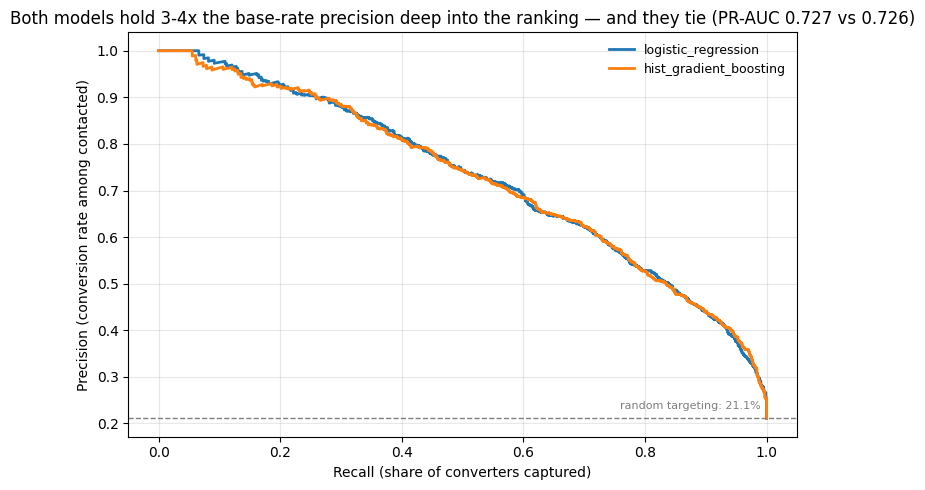

In [4]:
probas = {name: m.predict_proba(split.X_test)[:, 1] for name, m in models.items()}

for metric in ("pr_auc", "roc_auc"):
    delta = paired_bootstrap_auc_delta(
        split.y_test, probas["logistic_regression"],
        probas["hist_gradient_boosting"], metric=metric,
    )
    print(f"GBM - LR, {metric}: {delta.delta:+.4f} "
          f"[{delta.ci_low:+.4f}, {delta.ci_high:+.4f}] "
          f"significant={delta.significant}")

fig, ax = plt.subplots(figsize=(7.5, 5))
for (name, proba), color in zip(probas.items(), [LR_COLOR, GBM_COLOR]):
    precision, recall, _ = precision_recall_curve(split.y_test, proba)
    ax.plot(recall, precision, color=color, linewidth=2, label=name)
base_rate = split.y_test.mean()
ax.axhline(base_rate, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.text(0.99, base_rate + 0.02, f"random targeting: {base_rate:.1%}",
        ha="right", fontsize=8, color=NEUTRAL_COLOR)
ax.set_xlabel("Recall (share of converters captured)")
ax.set_ylabel("Precision (conversion rate among contacted)")
ax.set_title("Both models hold 3-4x the base-rate precision deep into the "
             "ranking — and they tie (PR-AUC 0.727 vs 0.726)")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Notebook 07's conclusion transfers: **the tuned GBM ties logistic regression on conversion too** (ΔPR-AUC −0.002 [−0.006, +0.002], ΔROC-AUC +0.001 [−0.001, +0.003] — both straddle zero). The logistic regression is again the production choice: same ranking power, directly readable drivers, honest probabilities. The rest of the notebook reads its scores.

## 5. Calibration: the Probabilities a Budget Can Trust

A campaign planner multiplies predicted probabilities by contact counts; miscalibrated scores turn into wrong budgets. Unweighted training was chosen precisely to keep these honest.

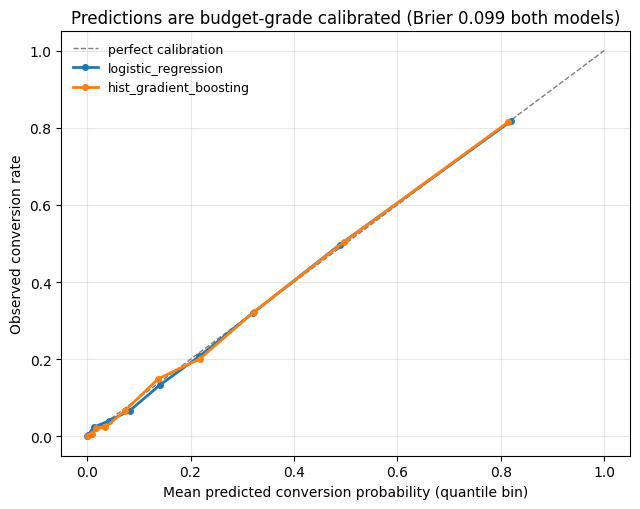

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot([0, 1], [0, 1], color=NEUTRAL_COLOR, linestyle="--", linewidth=1,
        label="perfect calibration")
for (name, proba), color in zip(probas.items(), [LR_COLOR, GBM_COLOR]):
    cal = calibration_table(split.y_test, proba, n_bins=10)
    ax.plot(cal["mean_predicted"].to_numpy(), cal["observed_rate"].to_numpy(),
            marker="o", markersize=4, linewidth=2, color=color, label=name)
brier = metrics_table.set_index("model")["brier"]
ax.set_xlabel("Mean predicted conversion probability (quantile bin)")
ax.set_ylabel("Observed conversion rate")
ax.set_title(f"Predictions are budget-grade calibrated "
             f"(Brier {brier['logistic_regression']:.3f} both models)")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Campaign Economics: Contact the Top-k

The ranking translated into outreach terms: contact the top k% by predicted conversion probability, and compare against contacting the same number of users at random (whose precision is the 21.1% base rate).

,fraction_targeted,n_contacted,precision,share_of_positives_captured,lift_vs_random
0,0.05,373,0.9169,0.2171,4.3446
1,0.10,746,0.8190,0.3879,3.8809
2,0.20,1493,0.6577,0.6235,3.1166
3,0.30,2239,0.5453,0.7752,2.5840
4,0.50,3732,0.3952,0.9365,1.8728


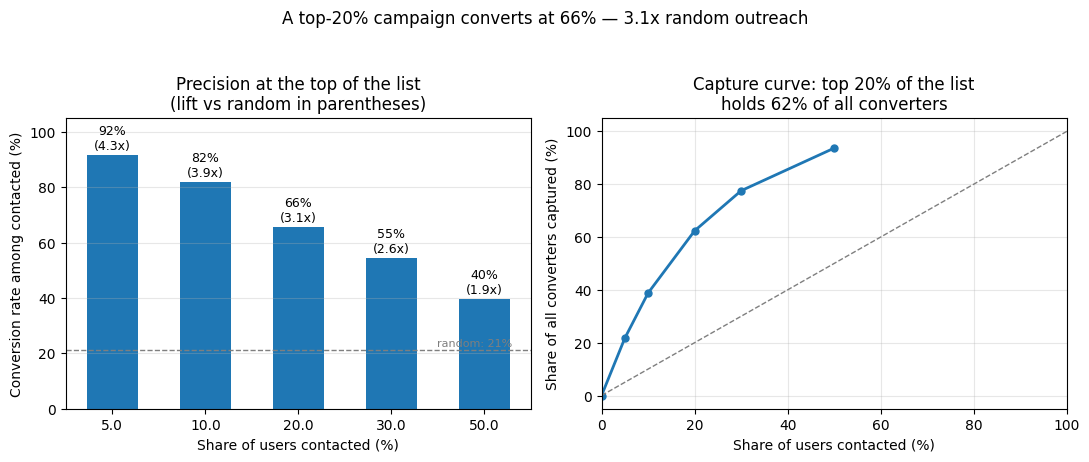

Chosen campaign size: top 20% of the ranked list
  full-population equivalent: ~7,462 contacts
  expected conversions among contacted: ~4,910 of 7,875 (62%)
  contacts per conversion: 1.52 (random outreach: 4.74)


In [6]:
chosen = "logistic_regression"
campaign = lift_table(split.y_test, probas[chosen],
                      fractions=(0.05, 0.10, 0.20, 0.30, 0.50))
display(campaign.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
fracs = campaign["fraction_targeted"] * 100
ax = axes[0]
bars = ax.bar(fracs.astype(str), campaign["precision"].to_numpy() * 100,
              color=LR_COLOR, width=0.55)
for bar, v, lift in zip(bars, campaign["precision"] * 100,
                        campaign["lift_vs_random"]):
    ax.annotate(f"{v:.0f}%\n({lift:.1f}x)", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
ax.axhline(split.y_test.mean() * 100, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.text(4.3, split.y_test.mean() * 100 + 1.5, "random: 21%", ha="right",
        fontsize=8, color=NEUTRAL_COLOR)
ax.set_xlabel("Share of users contacted (%)")
ax.set_ylabel("Conversion rate among contacted (%)")
ax.set_title("Precision at the top of the list\n(lift vs random in parentheses)")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.plot(np.append(0, fracs.to_numpy()),
        np.append(0, campaign["share_of_positives_captured"].to_numpy() * 100),
        marker="o", markersize=5, color=LR_COLOR, linewidth=2)
ax.plot([0, 100], [0, 100], color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.set_xlabel("Share of users contacted (%)")
ax.set_ylabel("Share of all converters captured (%)")
ax.set_title("Capture curve: top 20% of the list\nholds 62% of all converters")
ax.set_xlim(0, 100)
ax.grid(alpha=0.3)
fig.suptitle("A top-20% campaign converts at 66% — 3.1x random outreach",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

top20 = campaign.set_index("fraction_targeted").loc[0.20]
population_size = len(split.X_train) + len(split.X_test)
total_converters = int(round((split.y_train.sum() + split.y_test.sum())))
print(f"Chosen campaign size: top 20% of the ranked list")
print(f"  full-population equivalent: ~{population_size * 0.2:,.0f} contacts")
print(f"  expected conversions among contacted: "
      f"~{top20['share_of_positives_captured'] * total_converters:,.0f} "
      f"of {total_converters:,} ({top20['share_of_positives_captured']:.0%})")
print(f"  contacts per conversion: {1 / top20['precision']:.2f} "
      f"(random outreach: {1 / split.y_test.mean():.2f})")

**The defensible campaign size is the top 20%.** The top 5–10% is nearly saturated (92% and 82% precision — these users convert almost regardless, which is an uplift red flag, below), while at 20% the list still converts at 66% (3.1× random) and already covers 62% of all converters: ~7,460 contacts for ~4,900 expected conversions, **1.52 contacts per conversion versus 4.74 under random outreach** — a 3× outreach-cost reduction at equal coverage.

One caveat carries over from notebook 09 and belongs in any campaign brief: this model ranks **who will convert**, not **who converts because of the campaign**. The 92%-precision top slice is full of users who would likely convert unaided; the incremental (uplift) view would target further down the list. Propensity ranking is the right tool for prioritizing spend and capacity — but the campaign should ship with a holdout so its *incremental* conversion effect is measured, notebook-06 style.

## 7. What Drives Conversion — versus What Drove Churn

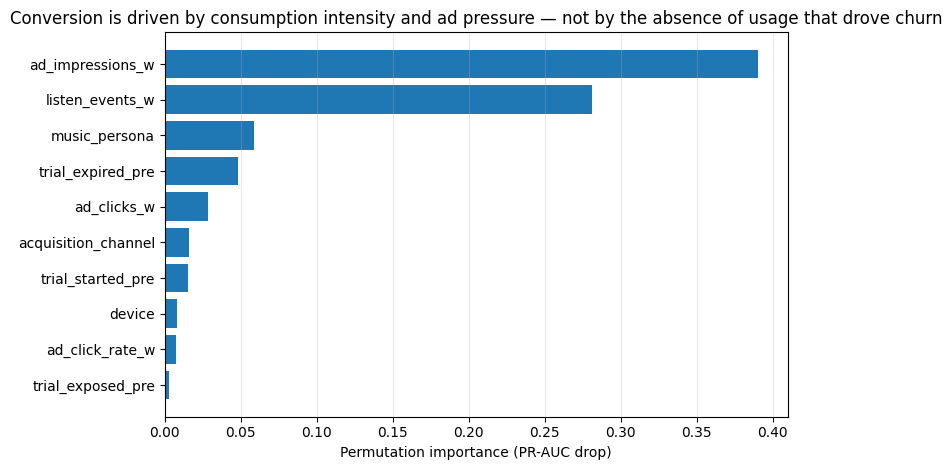

In [7]:
importance = permutation_importance(
    log_model, split.X_test, split.y_test, scoring="average_precision",
    n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1,
)
imp = (pd.Series(importance.importances_mean, index=split.X_test.columns)
       .sort_values().tail(10))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(imp.index, imp.to_numpy(), color=LR_COLOR)
ax.set_xlabel("Permutation importance (PR-AUC drop)")
ax.set_title("Conversion is driven by consumption intensity and ad pressure — "
             "not by the absence of usage that drove churn")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The two problems are mirror images. Churn (notebooks 05/07) was driven by *absence*: few sessions, few active days. Conversion is driven by *intensity on the free tier*: ad impressions (the strongest signal — heavy exposure to the free tier's friction) and listening volume dominate, with listener persona, an expired trial, and ad clicks behind them. The upsell pitch writes itself from the feature story: heavy listeners who keep hitting ads — especially those whose trial has lapsed — are the conversion market.

## 8. Key Findings

Task: rank never-paid users by 30-day paid-conversion probability for upsell targeting. Population 37,311, base rate 21.1% (landmark design; the audit section documents why the snapshot framing is untrainable and where the README's 17.4% figure comes from).

- **The ranking is strong and honest: PR-AUC 0.727 (vs 0.211 for random), ROC-AUC 0.894, Brier 0.099 with near-perfect calibration** — probabilities a campaign budget can multiply.
- **Notebook 07's conclusion transfers to conversion:** the tuned GBM ties logistic regression (ΔPR-AUC −0.002, 95% CI [−0.006, +0.002]) — the interpretable model is again the production choice, now confirmed on a second prediction task.
- **Campaign economics, top 20% of the list: 66% conversion among contacted (3.1× random), 62% of all converters covered, 1.52 contacts per conversion vs 4.74 at random** — a 3× outreach-cost reduction, with the top 5% (92% precision) flagged as likely sure-things better handled by the uplift lens of notebook 09.
- **Notebook 03/04's correlational drivers survive prediction:** referral converts at 29.9% vs paid social's 14.3%, and content engagement doubles conversion (29.9% vs 16.3%) — but the strongest *predictive* signals are ad exposure and listening volume: churn is about too little listening; conversion is about too much listening on a free tier.
- **Protocol frozen for the future:** population/label/leakage rules live in `sql/build_conversion_table.sql` + `src/conversion_modeling.py` (leakage guard included), and the baseline metrics above are persisted in the module docstring so the next conversion notebook can gate on reproduction the way 07 gated on 05.

**Caveats.** Simulated data; one landmark date, so seasonality is unobserved — a production version would validate on rolling landmarks. Propensity ≠ incrementality: the model prioritizes outreach, and the campaign's causal effect needs a holdout (or the notebook-09 uplift machinery) to measure. The 17.4% README baseline is a different denominator (all users, in-window) than this cohort's 21.1% forward rate; both are reported to keep the numbers reconciled.